In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv('/content/Churn_Modelling.csv')

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

In [ ]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [ ]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isnull().sum()

,0
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Exited,0


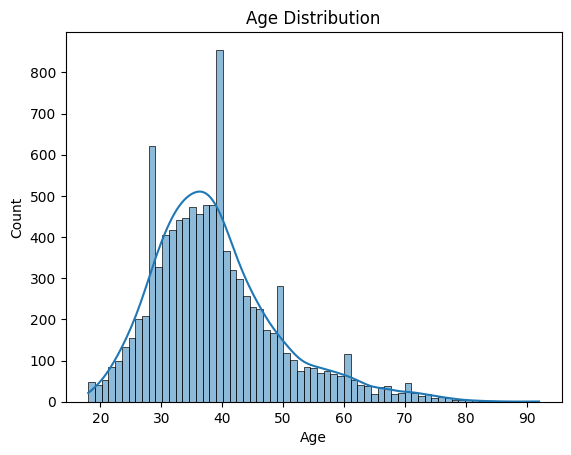

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

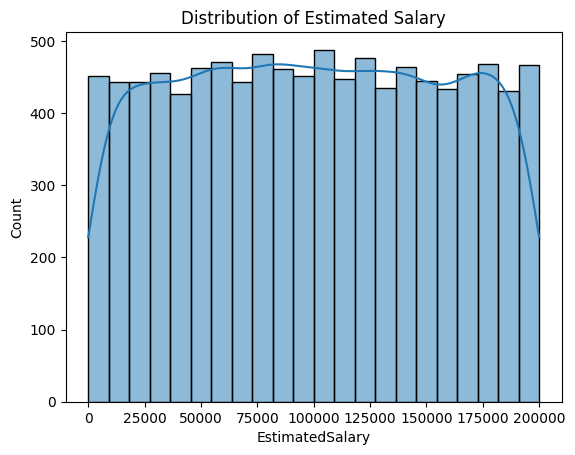

In [48]:
sns.histplot(df['EstimatedSalary'], kde=True)
plt.title('Distribution of Estimated Salary')
plt.show()

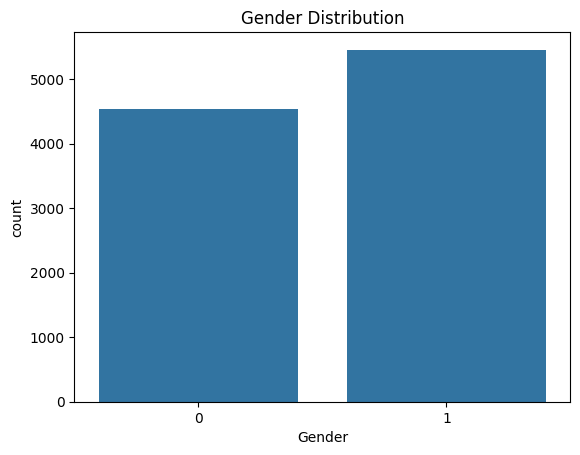

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

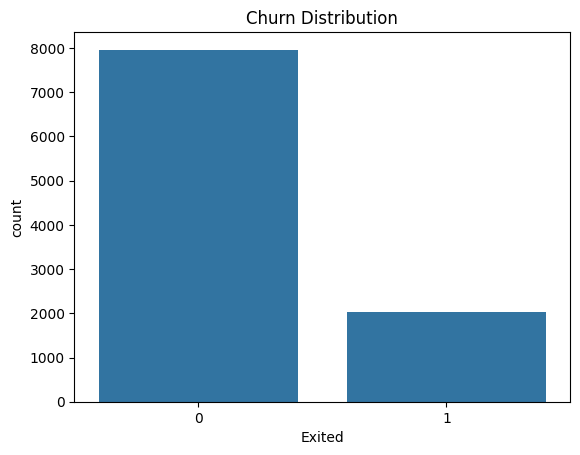

In [ ]:
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution')
plt.show()

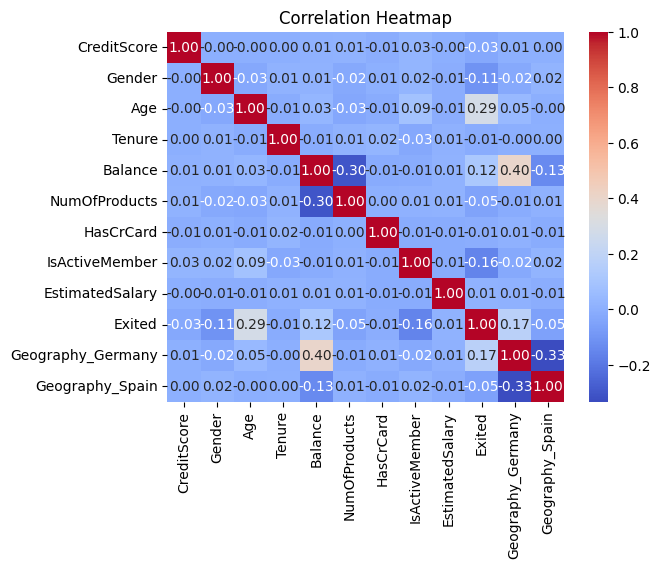

In [ ]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.89      0.82      0.86      1593
           1       0.47      0.61      0.53       407

    accuracy                           0.78      2000
   macro avg       0.68      0.71      0.69      2000
weighted avg       0.80      0.78      0.79      2000

ROC-AUC Score: 0.7146136891899603


In [51]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print(classification_report(y_test, y_pred_nb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1593
           1       0.42      0.57      0.48       407

    accuracy                           0.75      2000
   macro avg       0.65      0.68      0.66      2000
weighted avg       0.79      0.75      0.77      2000

ROC-AUC Score: 0.6836852260581074


In [ ]:
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print('SVM Classification Report:')
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1593
           1       0.41      0.53      0.46       407

    accuracy                           0.75      2000
   macro avg       0.64      0.67      0.65      2000
weighted avg       0.78      0.75      0.76      2000



In [54]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Decision Tree Classification Report:')
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1593
           1       0.41      0.57      0.48       407

    accuracy                           0.74      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.78      0.74      0.76      2000



ROC-AUC KNN: 0.78
ROC-AUC Naive Bayes: 0.76
ROC-AUC SVM: 0.74
ROC-AUC Decision Tree: 0.68


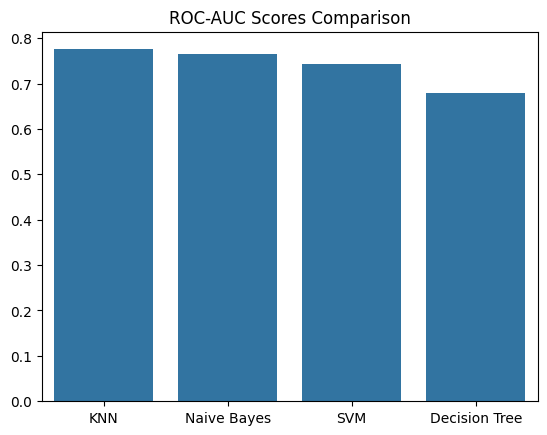

In [ ]:
roc_knn = roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1])
roc_nb = roc_auc_score(y_test, nb.predict_proba(X_test)[:, 1])
roc_svm = roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1])
roc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

print(f'ROC-AUC KNN: {roc_knn:.2f}')
print(f'ROC-AUC Naive Bayes: {roc_nb:.2f}')
print(f'ROC-AUC SVM: {roc_svm:.2f}')
print(f'ROC-AUC Decision Tree: {roc_dt:.2f}')

models = ['KNN', 'Naive Bayes', 'SVM', 'Decision Tree']
roc_scores = [roc_knn, roc_nb, roc_svm, roc_dt]

sns.barplot(x=models, y=roc_scores)
plt.title('ROC-AUC Scores Comparison')
plt.show()

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    }

for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")



Model: KNN
Accuracy: 0.7785
Precision: 0.4660377358490566
Recall: 0.6068796068796068
F1 Score: 0.5272145144076841
ROC AUC: 0.7754040635396566

Model: Naive Bayes
Accuracy: 0.754
Precision: 0.42201834862385323
Recall: 0.5651105651105651
F1 Score: 0.4831932773109244
ROC AUC: 0.7641539844929675

Model: SVM
Accuracy: 0.8085
Precision: 0.5242914979757085
Recall: 0.6363636363636364
F1 Score: 0.5749167591564928
ROC AUC: 0.8390031017149661

Model: Decision Tree
Accuracy: 0.744
Precision: 0.4080560420315236
Recall: 0.5724815724815725
F1 Score: 0.47648261758691207
ROC AUC: 0.6801516462533412
